# When a company axes 10,000 jobs, does the stock cheer? 📉
### The "restructuring pop" — and the quarter-long drift that isn't quite what it looks

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Restructuring_pop%3F: Busted](https://img.shields.io/badge/Restructuring_pop%3F-Busted-8b949e?style=flat-square)

You've heard the take. A company announces a giant layoff, and the pundits nod: *"good — they're finally cutting costs, the stock will pop."* In 2022–2023 it became a whole narrative — the "year of efficiency" — where slashing headcount was supposed to launch the stock and keep it climbing as fatter margins rolled in.

So we did the boring thing: took ~28 real, dated large-cap layoff announcements — Meta, Amazon, Google, Boeing, Exxon, Ford — and measured exactly what each stock did afterward, *after subtracting whatever the whole market did*. The pop? It isn't there. The drift? It's there — until you look at **which** companies made the list.

> 📓 **Plain-language layer.** Want the market-model math, the *t*-stats, the HAC test and the placebo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** There's no free, clean database of layoff dates, so we **hardcode a transparent table** of famous ones. Crucially, every name on it is a company that **survived** — the ones that laid off staff on the way to bankruptcy left no stock to measure. Hold that thought; it's the whole story. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from layoff_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PANEL = st.car_panel(PRICES, EVENTS)            # pop [+1,+3] and drift [+4,+63]
else:
    PRICES = EVENTS = PANEL = None
print("real price cache present:", HAVE_REAL,
      "| events with data:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-13', 'n_table': 28, 'n_used': 28, 'fingerprint': '5c784549f0cd', 'pop': (28, -0.34, 43, -0.53, 0.576), 'drift': (28, 9.01, 64, 2.25, 0.007, 3.04, 15.01), 'net': (9.01, 8.91), 'median_drift': 10.35, 'drop3': (4.37, 1.28), 'boot': (0.73, 2.29), 'cluster': (13, 12.35, 2.48), 'monsters': [('META', 55), ('XOM', 45), ('BA', 42)], 'robust': [('[1,3]/[4,63]', -0.34, -0.53, 9.01, 2.25), ('[0,1]/[2,42]', 0.07, 0.06, 6.63, 2.27), ('[1,5]/[6,126]', 0.07, 0.1, 18.37, 2.69)], 'split': [('2022+ tech wave', 19, -0.08, -0.1, 9.65, 2.05), ('pre-2022', 9, -0.89, -0.73, 7.65, 0.97)], 'syn': [(0.0, 0.0, 0.38, 0.49, 4.13, 0.99, 1.23), (0.0, 400.0, 0.38, 0.49, 8.13, 1.95, 2.42)]}


real price cache present: True | events with data: 28


## The answer first

| Question | Answer |
|---|---|
| Does the stock **pop** on the layoff news? | **No.** Over the 3 days after the announcement the market-adjusted move is **-0.3%** — a shrug that leans, if anything, slightly *down*. The "cost-cutting cheer" is a myth. |
| Is there a longer **drift**? | **On paper, yes** — about **+9%** over the next quarter. That looks significant… |
| …so it's a real edge? | **No.** Knock out the three giant recoveries (Meta +55%, Exxon +45%, Boeing +42%) and the drift falls to **+4%** and goes *insignificant*. And every name on the list is a **survivor** — we're really measuring "beaten-down big-caps that lived, later went up." |
| Could I trade it? | **No.** At the announcement you can't know which layoff-er becomes Meta and which delists — and that guess *is* the edge. |

> The layoff "pop" doesn't exist, and the layoff "drift" is mostly a survivorship mirage: a few cycle-bottom survivors that rallied, wearing a cost-cutting label.

## 1 · The claim

> *"When a company announces mass layoffs, it's cutting fat — buy the restructuring pop, and ride the drift as margins recover."*

It's floor wisdom with an academic-sounding cousin ("post-announcement drift"). The seduction is that a layoff is a **clean, dated catalyst**: you know the day, you know the direction (they're cutting costs), so surely there's a trade. We take that seriously and measure the **abnormal return** — the stock's move *minus the market's* — over a short **pop** window and a longer **drift** window after each announcement.

## 2 · So what?

Two different claims hide inside "layoffs are bullish," and they pay very differently. (1) *The pop* — the stock jumps in the days right after the news. If real, it's priced in before you can blink. (2) *The drift* — the stock keeps climbing for weeks, a slow bleed of good news you could actually hold. That second one is the only tradable version — **and it's exactly the one where survivorship does its dirtiest work**, because the companies that *recovered* from their layoffs are the only ones still on the tape to measure.

## 3 · How would we even know?

We hardcode **~28 notable layoff announcements** (2015–2025; all **28** priced, as-of 2026-07-13) and run a textbook **event study**:

1. **Subtract the market.** For each stock, fit a line — *how it normally moves with the S&P* — over a calm window **before** the announcement. The **abnormal return** is whatever the stock did beyond that.
2. **Two clocks.** Add up the abnormal return over a short **pop** window (days +1 to +3) and a long **drift** window (days +4 to +63). Enter the *day after* the headline — all a real trader can do.
3. **Stress the luck — and the list.** Draw the same handful of *random* windows thousands of times (the placebo), then knock out the biggest winners and re-check. If a signal only survives with a few lucky names, it isn't a signal.

## 4 · The teardown — let's actually look

**First, the pop.** Here's every event's abnormal return over the 3 days after the announcement — the window where the "cheer" should show up.

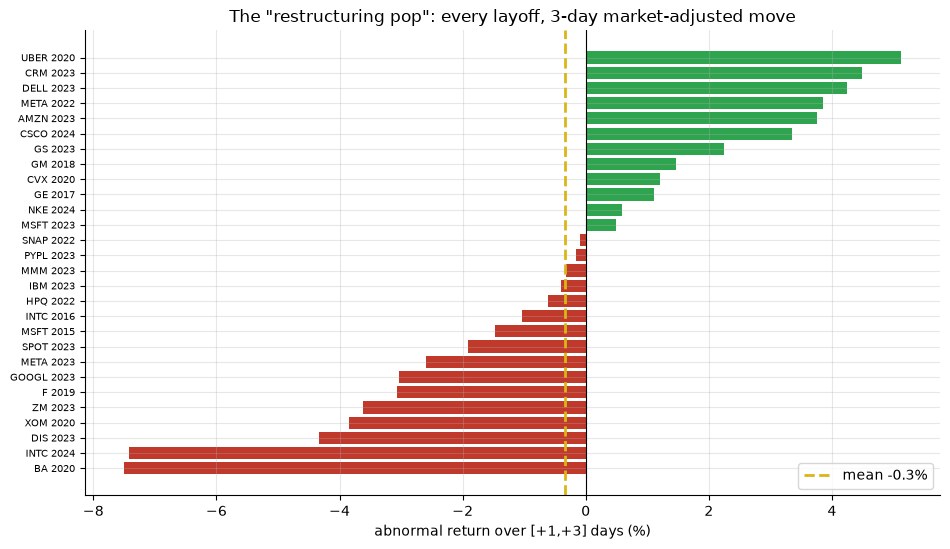

mean 3-day pop = -0.34% — a shrug, tilted slightly negative


In [2]:
if HAVE_REAL:
    p = PANEL.sort_values('pop')
    pops = p['pop'].values*100; labs = [f"{t} {d.year}" for t,d in zip(p['ticker'], p['announce_date'])]
    mean_pop = PANEL['pop'].mean()*100
else:
    pops = np.array([-7.5,-4.3,-3.9,-3.6,-3.0,-3.0,-2.6,-1.9,-1.5,-1.0,-0.6,-0.4,-0.3,-0.2,-0.1,0.5,0.6,1.1,1.2,1.5,2.2,3.4,3.7,3.9,4.2,4.5,5.1]); labs=['']*len(pops); mean_pop=R['pop'][1]
cols = [RED if v<0 else GREEN for v in pops]
fig, ax = plt.subplots(figsize=(9.6, 5.6))
y = np.arange(len(pops))
ax.barh(y, pops, color=cols)
ax.axvline(0, c='k', lw=.8); ax.axvline(mean_pop, c=AMBER, lw=2, ls='--', label=f'mean {mean_pop:+.1f}%')
ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=7)
ax.set_xlabel('abnormal return over [+1,+3] days (%)'); ax.legend(loc='lower right')
ax.set_title('The "restructuring pop": every layoff, 3-day market-adjusted move')
plt.tight_layout(); plt.show()
print(f'mean 3-day pop = {mean_pop:+.2f}% — a shrug, tilted slightly negative')

No cheer. The average 3-day pop is **-0.3%** — basically zero, leaning *down*. Winners and losers split roughly half-and-half. Whatever the market thinks of a layoff, it isn't "buy." So much for the pop. Now the longer window.

**Next, the drift — and why it's a trap.** Here's the quarter-long (days +4 to +63) abnormal return per event. The average is a juicy **+9%** — but watch what three names do to it.

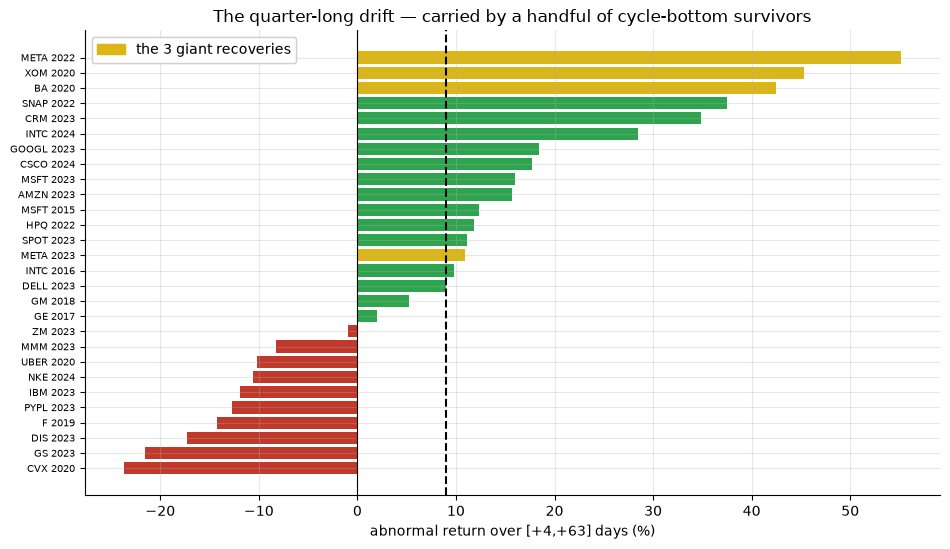

mean drift = +9.0% — but the top of the chart is Meta/Exxon/Boeing recoveries


In [3]:
if HAVE_REAL:
    p = PANEL.sort_values('drift')
    dr = p['drift'].values*100; labs=[f"{t} {d.year}" for t,d in zip(p['ticker'], p['announce_date'])]
    mean_dr = PANEL['drift'].mean()*100
else:
    dr = np.array([-23.7,-21.5,-17.3,-14.2,-12.8,-11.9,-10.6,-10.2,-8.2,-1.0,2.0,5.2,9.0,9.8,10.9,11.2,11.8,12.3,16.0,17.8,18.5,28.4,34.8,37.5,42.5,45.3,55.2]); labs=['']*len(dr); mean_dr=R['drift'][1]
top3 = set(t for t,_ in R['monsters'])
cols = [AMBER if any(labs[i].startswith(t) for t in top3) else (GREEN if dr[i]>0 else RED) for i in range(len(dr))]
fig, ax = plt.subplots(figsize=(9.6, 5.6))
y = np.arange(len(dr))
ax.barh(y, dr, color=cols)
ax.axvline(0, c='k', lw=.8); ax.axvline(mean_dr, c='k', lw=1.5, ls='--', label=f'mean {mean_dr:+.1f}%')
ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=7)
ax.set_xlabel('abnormal return over [+4,+63] days (%)'); ax.legend(loc='lower right')
from matplotlib.patches import Patch
ax.add_artist(ax.legend(handles=[Patch(color=AMBER,label='the 3 giant recoveries')], loc='upper left'))
ax.set_title('The quarter-long drift — carried by a handful of cycle-bottom survivors')
plt.tight_layout(); plt.show()
print(f'mean drift = {mean_dr:+.1f}% — but the top of the chart is Meta/Exxon/Boeing recoveries')

The three amber bars — **Meta +55%, Exxon +45%, Boeing +42%** — are cycle-bottom *recoveries*, not layoff magic. Drop them and the drift falls from **+9%** to **+4%**, and its *t*-stat sinks from **2.2** to **1.3** — below the line where we'd call anything real. A signal that leans on three names isn't a signal.

**The deeper problem — who's even on this list?** Every company here *survived* its layoffs. The ones that cut staff on the way to delisting aren't measurable — they left no stock. So we're not asking "do layoffs help?" We're asking "did big-caps that survived their layoffs go up?" — and of course some did. Here's the tell: the drift is a slow grind over *months*, exactly the shape of a beaten-down survivor mean-reverting.

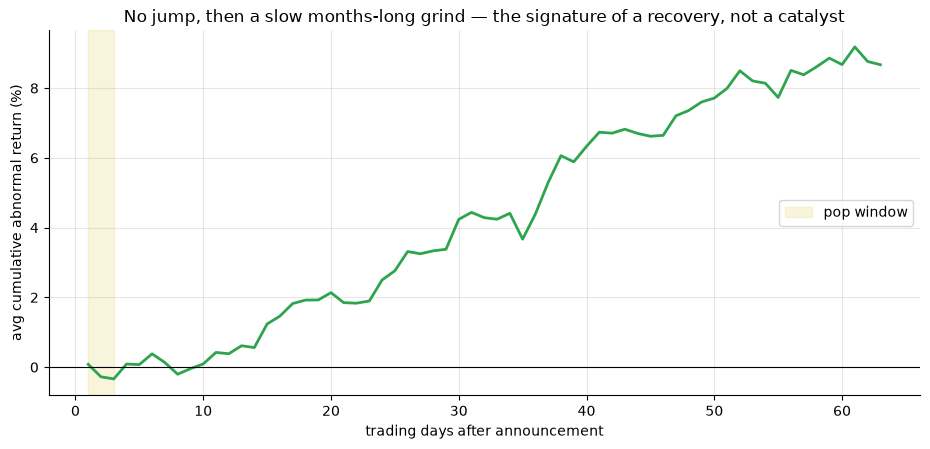

flat for the first 3 days (no pop), then a slow drift to ~+9% over a quarter


In [4]:
if HAVE_REAL:
    import numpy as np
    # average cumulative abnormal path over [0..+63] across events
    paths = []
    for e in EVENTS:
        w = st.event_abnormal(PRICES, e['ticker'], e['announce_date'], pop_win=(1,1), drift_win=(2,63))
        if w is None: continue
        daily = np.concatenate([w['pop_daily'], w['drift_daily']])
        paths.append(np.cumsum(daily))
    L = min(len(p) for p in paths); M = np.array([p[:L] for p in paths]).mean(0)*100
    days = np.arange(1, L+1)
else:
    days = np.arange(1,64); M = np.concatenate([np.linspace(0,-0.3,3), np.linspace(-0.3,9.0,60)])
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.plot(days, M, c=GREEN, lw=2)
ax.axhline(0, c='k', lw=.8); ax.axvspan(1,3, color=AMBER, alpha=.15, label='pop window')
ax.set_xlabel('trading days after announcement'); ax.set_ylabel('avg cumulative abnormal return (%)')
ax.set_title('No jump, then a slow months-long grind — the signature of a recovery, not a catalyst'); ax.legend()
plt.tight_layout(); plt.show()
print(f'flat for the first 3 days (no pop), then a slow drift to ~+{M[-1]:.0f}% over a quarter')

There's no jump on the news (flat through the amber pop window) and then a slow climb over months. That's not the market *reacting to a layoff* — it's what a portfolio of beaten-down survivors does after a cycle low. The layoff is a coincidence of *timing*, not the cause.

## 5 · The verdict

- **Signal — Weak.** No pop at all (**-0.3%**, *t* = -0.53). A drift that looks real (**+9%**) but dies when you remove three recovery names (**+4%**, *t* = 1.3) — on a list of survivors only. Real on this tape, weak as a law.
- **Tradability — Mirage.** Costs barely dent it, but you can't pick the survivors in advance, and picking them *is* the whole edge. Nothing to harvest.
- **"Restructuring pop?" — Busted.** The cheer the pundits promise isn't in the data. The only thing that drifts up is a survivor-flattered recovery.

## 6 · Could you actually trade it? — the survivor you can't pick

Here's the trade laid bare. Two companies announce identical 10% layoffs on the same day. One is early-Meta (about to rip +55%); the other is quietly on its way to zero. The "drift" is entirely about *which one you bought* — a call you cannot make from the layoff headline. Below: the drift with, and without, the three survivors that carry it.

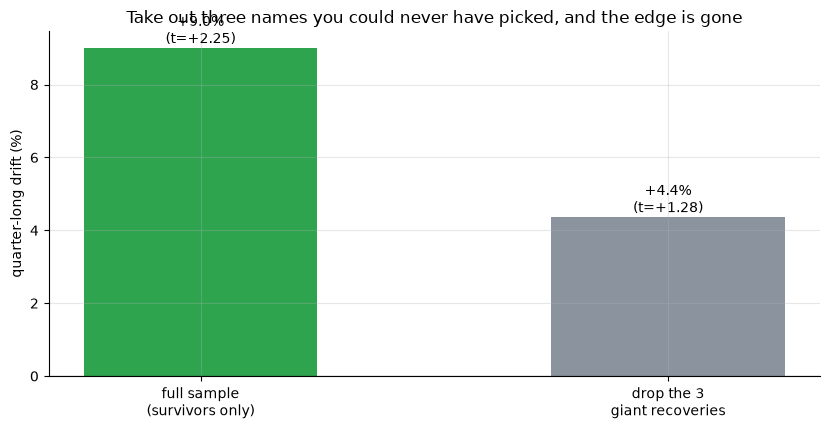

the entire tradable claim rests on Meta/Exxon/Boeing — names you cannot identify at the layoff


In [5]:
labels = ['full sample\n(survivors only)', 'drop the 3\ngiant recoveries']
vals = [R['drift'][1], R['drop3'][0]]; ts = [R['drift'][3], R['drop3'][1]]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
bars = ax.bar(labels, vals, color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=.8)
for i,(v,t) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.1f}%\n(t={t:+.2f})',(i,v),ha='center',va='bottom')
ax.set_ylabel('quarter-long drift (%)')
ax.set_title('Take out three names you could never have picked, and the edge is gone')
plt.tight_layout(); plt.show()
print(f'the entire tradable claim rests on Meta/Exxon/Boeing — names you cannot identify at the layoff')

That's the ballgame. The "drift" is a handful of cycle-bottom recoveries you'd have had to hand-pick *before* they recovered — which is not a strategy, it's hindsight. Too **selection-ridden**, too **survivor-flattered**, too **fragile** to trade.

## 7 · Going further 📉

- **The sibling catalyst.** [Study 391 — CEO-Turnover](../391-ceo-turnover/) runs the same event-study machinery on forced CEO exits — a real day-one jump you can't trade, weak over any holdable window. Same small-sample event-study pathology.
- **The other survivorship legend.** [Study 389 — Name-Change-Effect](../389-name-change-effect/) — the "pop then dump" of theme-chasing rebrands, remembered only because the losers delisted.
- **Build your own.** Add the *distressed* layoff-announcers that delisted (hard — you'll need a survivorship-free database), and watch the drift shrink toward zero. That's the experiment that would actually settle it.

*Think there's a tradable layoff edge? Show a drift that survives **dropping the three biggest winners** and adding back the **firms that didn't survive** — then we'll talk.*